In [1]:
import sounddevice as sd
import numpy as np
import soundfile as sf
from src.audio_device import AudioDevice
from src.sharc import Sharc
import matplotlib.pyplot as plt
import librosa
import mido

print(sd.query_devices())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Analogue 1 + 2 (8- Focusrite US, MME (8 in, 0 out)
   2 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  4 Realtek HD Audio 2nd output (Re, MME (0 in, 2 out)
   5 Speakers (8- Focusrite USB Audi, MME (0 in, 8 out)
   6 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   7 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   8 Analogue 1 + 2 (8- Focusrite USB Audio), Windows DirectSound (8 in, 0 out)
   9 Microphone Array (Intel® Smart Sound Technology (Intel® SST)), Windows DirectSound (4 in, 0 out)
  10 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  11 Realtek HD Audio 2nd output (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  12 Speakers (8- Focusrite USB Audio), Windows DirectSound (0 in, 8 out)
  13 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  14 Speakers (8- Focusrite USB Audio), Windows WASAPI (0 in, 2 out)
  1

In [2]:
arthur, sr = sf.read('data/arthur_clip_48k.wav')

fs = 96_000
arthur_96 = librosa.resample(arthur, orig_sr=sr, target_sr=fs)


ad = AudioDevice(fs, in_device=1, out_device=4)

In [3]:
sharc = Sharc(arthur_96, ad)


Using output: USB2.0-MIDI 3
Using input:  USB2.0-MIDI 2


In [4]:
sharc.no_cancel(1)

In [5]:
error_raw, ref_raw = sharc.record_sine_sweep()

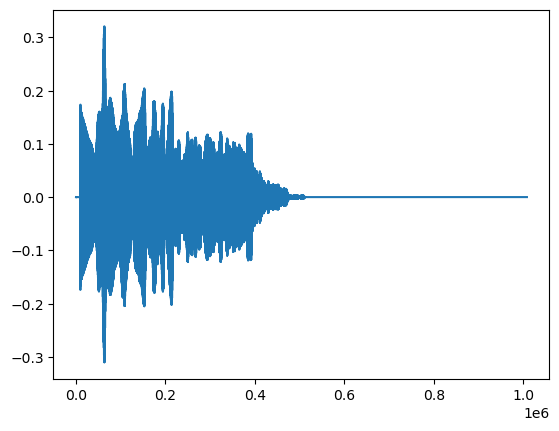

In [6]:
plt.plot(error_raw)

In [7]:
from src.measure_ir import *

In [8]:
sweep = make_sweep(fs=sharc.ad.fs)

error_ir = estimate_ir(
    error_raw,
    sweep,
    fs=sharc.ad.fs
)

ref_ir = estimate_ir(
    ref_raw,
    sweep,
    fs=sharc.ad.fs
)

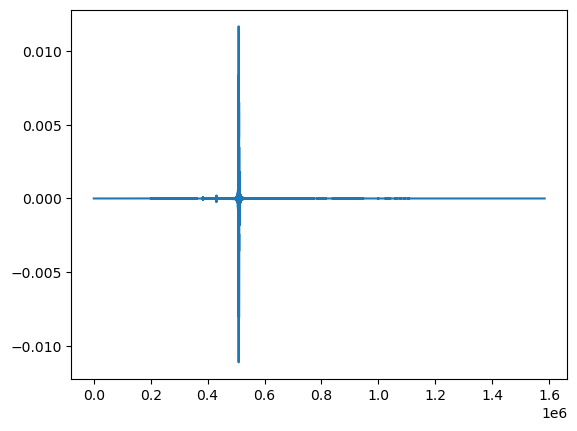

In [9]:
plt.plot(error_ir)

In [10]:
error_a, ref_a = align_irs_by_distance(error_ir, ref_ir, distance_cm=4.5, ir_len=256, fs=96000)

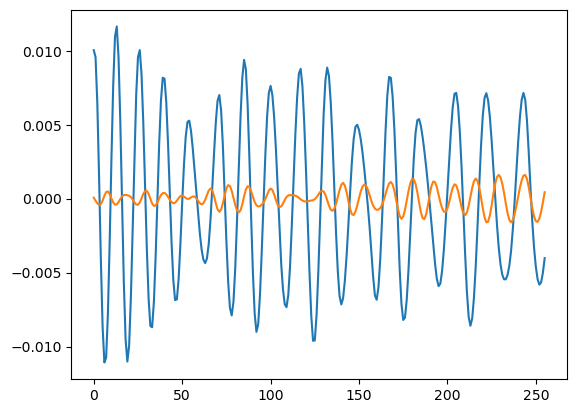

In [11]:
plt.plot(error_a)
plt.plot(ref_a)

peak: 508936
peak value: 0.0116440235


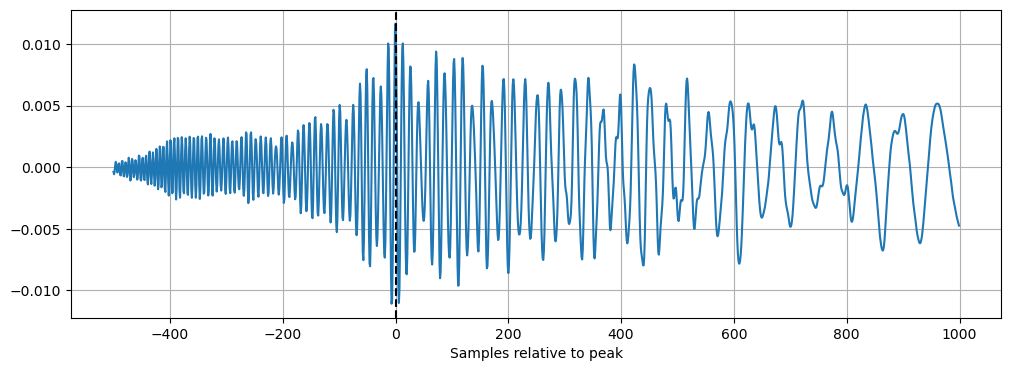

In [12]:
peak = np.argmax(np.abs(error_ir))
print("peak:", peak)
print("peak value:", error_ir[peak])

plt.figure(figsize=(12, 4))
plt.plot(
    np.arange(peak - 500, peak + 1000) - peak,
    error_ir[peak - 500:peak + 1000]
)
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Samples relative to peak")
plt.grid()
plt.show()

In [13]:
def make_sharc_sweep(
    fs=96_000,
    duration=6.0,
    f0=150.0,
    f1=22_000.0,
    fade=0.02,
    amplitude=0.5,
):
    N = int(fs * duration)
    fade_N = int(fs * fade)

    beta = np.float32(
        np.log(np.float32(f1 / f0)) / np.float32(duration)
    )

    q = np.float32(
        np.exp(beta / np.float32(fs))
    )

    phase_scale = np.float32(
        np.float32(2.0 * np.pi) * np.float32(f0) / beta
    )

    z = np.float32(1.0)

    sweep = np.empty(N, dtype=np.float32)

    for n in range(N):
        fade_gain = np.float32(1.0)

        if n < fade_N:
            fade_gain = np.float32(n) / np.float32(fade_N - 1)

        elif n >= N - fade_N:
            fade_gain = (
                np.float32(N - 1 - n) /
                np.float32(fade_N - 1)
            )

        phase = np.float32(
            phase_scale * np.float32(z - np.float32(1.0))
        )

        sweep[n] = np.float32(
            np.float32(amplitude) *
            fade_gain *
            np.sin(phase)
        )

        z = np.float32(z * q)

    return sweep

In [ ]:
sweep = make_sharc_sweep(fs=96_000)

error_ir = estimate_ir(
    error_raw,
    sweep,
    fs=96_000,
    f0=150,
    f1=22_000
)



peak: 511647
peak value: -0.07417805


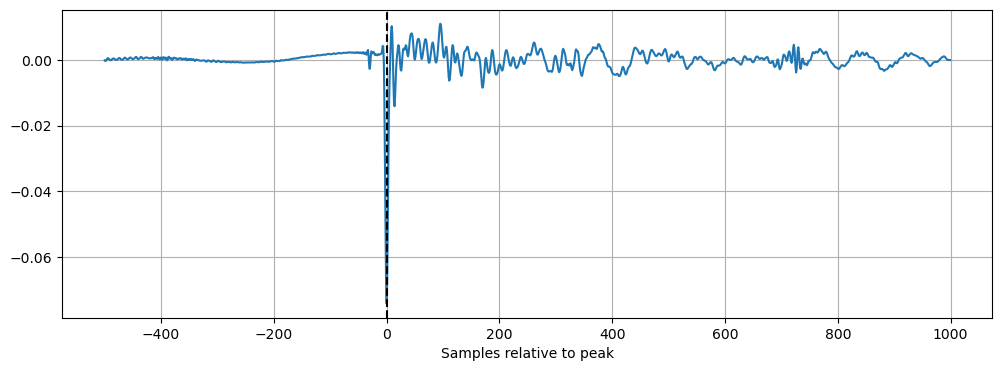

In [16]:
peak = np.argmax(np.abs(error_ir))
print("peak:", peak)
print("peak value:", error_ir[peak])

plt.figure(figsize=(12, 4))
plt.plot(
    np.arange(peak - 500, peak + 1000) - peak,
    error_ir[peak - 500:peak + 1000]
)
plt.axvline(0, color="k", linestyle="--")
plt.xlabel("Samples relative to peak")
plt.grid()
plt.show()

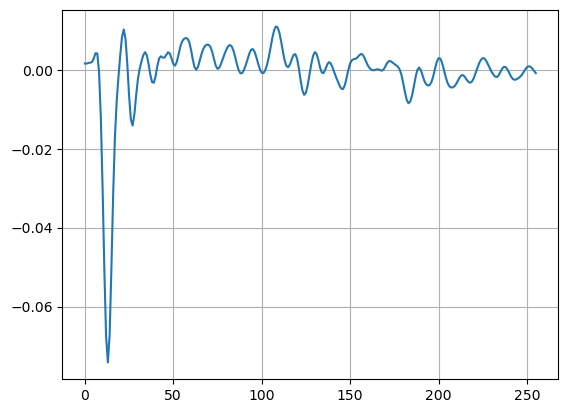

In [18]:
peak = np.argmax(np.abs(error_ir))

new_error_ir = error_ir[
    peak-13:peak + 256 - 13
]

plt.plot(new_error_ir)
plt.grid()
plt.show()

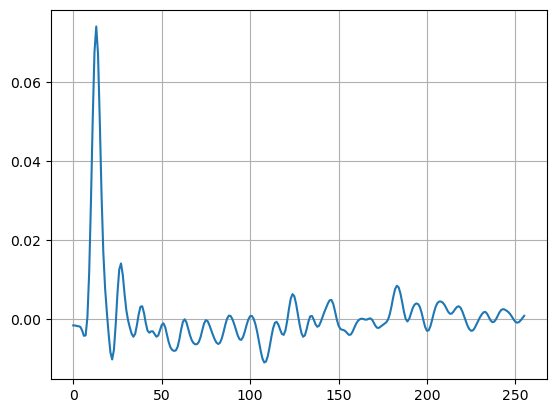

In [19]:
plt.plot(-new_error_ir)
plt.grid()
plt.show()

In [24]:
old_irs = np.load('./data/current_irs.npz')
old_error_ir, *_ = align_irs_by_distance(old_irs['error_ir'], old_irs['ref_ir'], distance_cm=4.5, ir_len=256)

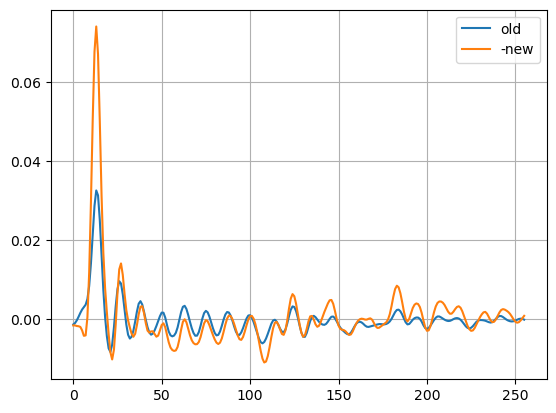

In [26]:
plt.plot(old_error_ir, label="old")
# plt.plot(new_error_ir, label="new")
plt.plot(-new_error_ir, label="-new")
plt.legend()
plt.grid()

In [27]:
print("corr(old, new): ",
      np.corrcoef(old_error_ir, new_error_ir)[0, 1])

print("corr(old, -new):",
      np.corrcoef(old_error_ir, -new_error_ir)[0, 1])

corr(old, new):  -0.9420067242420815
corr(old, -new): 0.9420067242420815


In [28]:
alpha = np.dot(old_error_ir, new_error_ir) / np.dot(new_error_ir, new_error_ir)

print("best scalar:", alpha)

best scalar: -0.45926312


In [7]:
sharc.sine_sweep()

In [4]:
def compare_test_tone_to_ir(
    error_mic,
    error_ir,
    fs=96000,
    freq=500.0,
    sharc_amp=0.05,
    trim_s=1.0,
):
    error_mic = np.asarray(error_mic)
    error_ir = np.asarray(error_ir).reshape(-1)

    # Remove start/end of recording.
    trim = int(trim_s * fs)
    x = error_mic[trim:-trim]

    # Estimate amplitude specifically at freq rather than broadband RMS.
    n = np.arange(len(x))
    c = np.cos(2 * np.pi * freq * n / fs)
    s = np.sin(2 * np.pi * freq * n / fs)

    a = 2.0 * np.dot(x, c) / len(x)
    b = 2.0 * np.dot(x, s) / len(x)

    measured_error_amp = np.sqrt(a*a + b*b)

    # Frequency response of measured IR at exactly freq.
    k = np.arange(len(error_ir))
    H = np.sum(
        error_ir * np.exp(-1j * 2*np.pi * freq * k / fs)
    )

    measured_gain = measured_error_amp / sharc_amp
    ir_gain = np.abs(H)

    ratio = measured_gain / ir_gain

    print(f"Measured error amplitude: {measured_error_amp:.6g}")
    print(f"Real SHARC->mic gain:     {measured_gain:.6g}")
    print(f"IR predicted gain:        {ir_gain:.6g}")
    print(f"Real / IR ratio:          {ratio:.6f}")
    print(f"Difference:               {20*np.log10(ratio):.2f} dB")

    return ratio

In [5]:
def record_test_tone(duration=5.0, settle=0.5):
    n = int(duration * fs)
    silence = np.zeros(n, dtype=np.float32)

    # Start SHARC tone first so it is already running when recording begins.
    sharc.play_test_tone(True)

    try:
        # time.sleep(settle)

        error_mic, ref_mic = ad.play(
            left=silence,
            right=silence,
        )
    finally:
        # Make sure we don't leave the panel screaming at 500 Hz if
        # recording throws an exception.
        sharc.play_test_tone(False)

    return error_mic, ref_mic

In [6]:
def test_tone_rms(duration=5.0, trim=1.0):
    error_mic, ref_mic = record_test_tone(duration=duration)

    trim_samples = int(trim * fs)

    if 2 * trim_samples >= len(error_mic):
        raise ValueError("trim is too large for recording duration")

    error_mid = error_mic[trim_samples:-trim_samples]
    ref_mid = ref_mic[trim_samples:-trim_samples]

    error_rms = np.sqrt(np.mean(error_mid.astype(np.float64) ** 2))
    ref_rms = np.sqrt(np.mean(ref_mid.astype(np.float64) ** 2))

    print(f"Error mic RMS: {error_rms:.9f}")
    print(f"Ref mic RMS:   {ref_rms:.9f}")

    return error_rms, ref_rms, error_mic, ref_mic

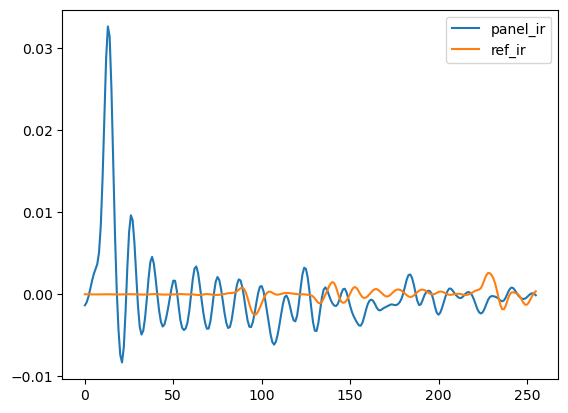

In [7]:
error_ir, ref_ir = sharc.prep_irs()

In [42]:
sharc.no_cancel(1)

In [21]:
e_300, r_300 = record_test_tone(duration=5.0)

In [25]:
e_400, r_400 = record_test_tone(duration=5.0)

In [ ]:
e_500, r_500 = record_test_tone(duration=5.0)

In [27]:
e_600, r_600 = record_test_tone(duration=5.0)

In [29]:
e_700, r_700 = record_test_tone(duration=5.0)

In [31]:
e_1000, r_1000 = record_test_tone(duration=5.0)

In [33]:
e_1500, r_1500 = record_test_tone(duration=5.0)

In [35]:
e_2000, r_2000 = record_test_tone(duration=5.0)

In [14]:
ratio = compare_test_tone_to_ir(
    error_tone,
    error_ir,
    fs=fs,
    freq=500.0,
    sharc_amp=0.05,
)

Measured error amplitude: 0.0225883
Real SHARC->mic gain:     0.451766
IR predicted gain:        0.251772
Real / IR ratio:          1.794349
Difference:               5.08 dB


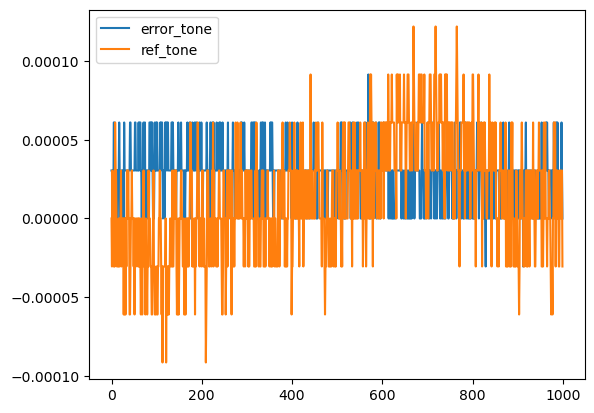

In [19]:
plt.plot(e_300[96_000:97_000], label="error_tone")
plt.plot(r_300[96_000:97_000], label="ref_tone")
plt.legend()
plt.show()

In [36]:
freqs = [300, 400, 500, 600, 700, 1000, 1500, 2000]
sharc_amp = 0.05
trim_s = 1.0

recordings = {
    300:  (e_300,  r_300),
    400:  (e_400,  r_400),
    500:  (e_500,  r_500),
    600:  (e_600,  r_600),
    700:  (e_700,  r_700),
    1000: (e_1000, r_1000),
    1500: (e_1500, r_1500),
    2000: (e_2000, r_2000),
}


def tone_amplitude(x, freq, fs, trim_s=1.0):
    x = np.asarray(x).reshape(-1)

    trim = int(trim_s * fs)
    x = x[trim:-trim]

    n = np.arange(len(x))
    phase = 2 * np.pi * freq * n / fs

    a = 2.0 * np.dot(x, np.cos(phase)) / len(x)
    b = 2.0 * np.dot(x, np.sin(phase)) / len(x)

    return np.sqrt(a*a + b*b)


def ir_gain_at_freq(ir, freq, fs):
    ir = np.asarray(ir).reshape(-1)
    n = np.arange(len(ir))

    H = np.sum(ir * np.exp(-1j * 2*np.pi * freq * n / fs))

    return np.abs(H)


results = []

for freq in freqs:
    error, ref = recordings[freq]

    error_amp = tone_amplitude(error, freq, fs, trim_s)
    ref_amp = tone_amplitude(ref, freq, fs, trim_s)

    real_gain = error_amp / sharc_amp
    ir_gain = ir_gain_at_freq(error_ir, freq, fs)

    ratio = real_gain / ir_gain
    ratio_db = 20 * np.log10(ratio)

    results.append([
        freq,
        error_amp,
        ref_amp,
        real_gain,
        ir_gain,
        ratio,
        ratio_db,
    ])

    print(
        f"{freq:4d} Hz | "
        f"error={error_amp:.6f} | "
        f"ref={ref_amp:.6f} | "
        f"real={real_gain:.4f} | "
        f"IR={ir_gain:.4f} | "
        f"real/IR={ratio:.3f} ({ratio_db:+.2f} dB)"
    )

 300 Hz | error=0.018665 | ref=0.001011 | real=0.3733 | IR=0.2853 | real/IR=1.309 (+2.34 dB)
 400 Hz | error=0.018521 | ref=0.001181 | real=0.3704 | IR=0.2770 | real/IR=1.337 (+2.52 dB)
 500 Hz | error=0.022605 | ref=0.001677 | real=0.4521 | IR=0.2518 | real/IR=1.796 (+5.08 dB)
 600 Hz | error=0.015743 | ref=0.000290 | real=0.3149 | IR=0.2352 | real/IR=1.339 (+2.54 dB)
 700 Hz | error=0.022116 | ref=0.005810 | real=0.4423 | IR=0.2214 | real/IR=1.998 (+6.01 dB)
1000 Hz | error=0.024658 | ref=0.003826 | real=0.4932 | IR=0.2006 | real/IR=2.458 (+7.81 dB)
1500 Hz | error=0.008122 | ref=0.001270 | real=0.1624 | IR=0.2262 | real/IR=0.718 (-2.87 dB)
2000 Hz | error=0.008735 | ref=0.001823 | real=0.1747 | IR=0.1250 | real/IR=1.397 (+2.91 dB)


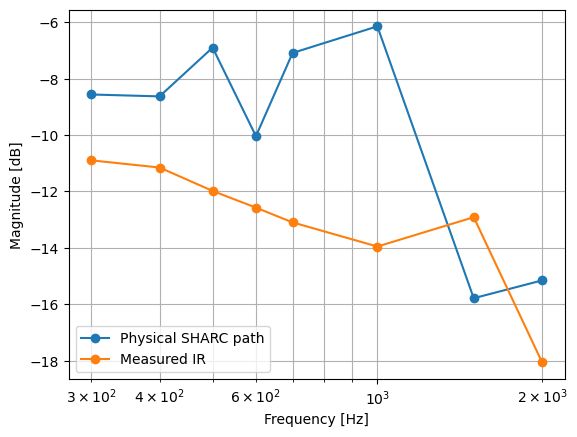

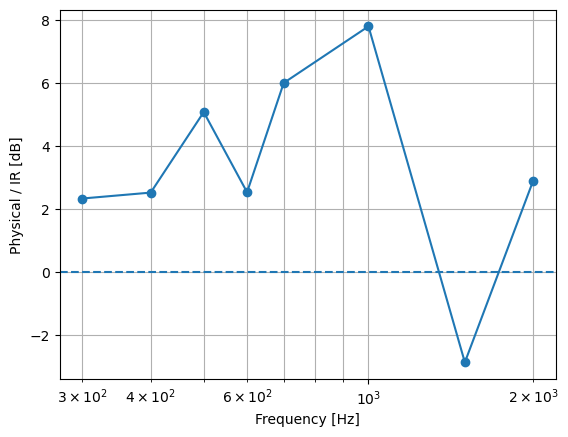

In [37]:
results = np.asarray(results)

f = results[:, 0]
real_gain = results[:, 3]
ir_gain = results[:, 4]
ratio = results[:, 5]
ratio_db = results[:, 6]


plt.figure()
plt.semilogx(f, 20*np.log10(real_gain), "o-", label="Physical SHARC path")
plt.semilogx(f, 20*np.log10(ir_gain), "o-", label="Measured IR")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.grid(True, which="both")
plt.legend()
plt.show()


plt.figure()
plt.semilogx(f, ratio_db, "o-")
plt.axhline(0, linestyle="--")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Physical / IR [dB]")
plt.grid(True, which="both")
plt.show()

In [39]:
e_500_2, r_500_2 = record_test_tone(duration=5.0)

In [41]:
e_1000_2, r_1000_2 = record_test_tone(duration=5.0)

In [43]:
e_1500_2, r_1500_2 = record_test_tone(duration=5.0)

In [44]:
repeat_recordings = {
    500:  (e_500,  e_500_2,  r_500,  r_500_2),
    1000: (e_1000, e_1000_2, r_1000, r_1000_2),
    1500: (e_1500, e_1500_2, r_1500, r_1500_2),
}

sharc_amp = 0.05
trim_s = 1.0


def tone_amplitude(x, freq, fs, trim_s=1.0):
    x = np.asarray(x).reshape(-1)

    trim = int(trim_s * fs)
    x = x[trim:-trim]

    n = np.arange(len(x))
    phase = 2 * np.pi * freq * n / fs

    a = 2.0 * np.dot(x, np.cos(phase)) / len(x)
    b = 2.0 * np.dot(x, np.sin(phase)) / len(x)

    return np.sqrt(a*a + b*b)


def ir_gain_at_freq(ir, freq, fs):
    ir = np.asarray(ir).reshape(-1)
    n = np.arange(len(ir))

    H = np.sum(
        ir * np.exp(-1j * 2*np.pi * freq * n / fs)
    )

    return np.abs(H)


for freq, (e1, e2, r1, r2) in repeat_recordings.items():

    e_amp1 = tone_amplitude(e1, freq, fs, trim_s)
    e_amp2 = tone_amplitude(e2, freq, fs, trim_s)

    r_amp1 = tone_amplitude(r1, freq, fs, trim_s)
    r_amp2 = tone_amplitude(r2, freq, fs, trim_s)

    real_gain1 = e_amp1 / sharc_amp
    real_gain2 = e_amp2 / sharc_amp

    ir_gain = ir_gain_at_freq(error_ir, freq, fs)

    ratio1 = real_gain1 / ir_gain
    ratio2 = real_gain2 / ir_gain

    ratio_db1 = 20 * np.log10(ratio1)
    ratio_db2 = 20 * np.log10(ratio2)

    repeat_diff_db = 20 * np.log10(real_gain2 / real_gain1)

    print(f"\n{freq} Hz")
    print(f"  Error amp #1:       {e_amp1:.6f}")
    print(f"  Error amp #2:       {e_amp2:.6f}")
    print(f"  Physical gain #1:   {real_gain1:.6f}")
    print(f"  Physical gain #2:   {real_gain2:.6f}")
    print(f"  Repeat difference:  {repeat_diff_db:+.3f} dB")
    print(f"  IR gain:             {ir_gain:.6f}")
    print(f"  Physical/IR #1:     {ratio1:.3f} ({ratio_db1:+.2f} dB)")
    print(f"  Physical/IR #2:     {ratio2:.3f} ({ratio_db2:+.2f} dB)")
    print(f"  Ref amp #1:         {r_amp1:.6f}")
    print(f"  Ref amp #2:         {r_amp2:.6f}")


500 Hz
  Error amp #1:       0.022605
  Error amp #2:       0.022604
  Physical gain #1:   0.452105
  Physical gain #2:   0.452080
  Repeat difference:  -0.000 dB
  IR gain:             0.251772
  Physical/IR #1:     1.796 (+5.08 dB)
  Physical/IR #2:     1.796 (+5.08 dB)
  Ref amp #1:         0.001677
  Ref amp #2:         0.001674

1000 Hz
  Error amp #1:       0.024658
  Error amp #2:       0.024518
  Physical gain #1:   0.493156
  Physical gain #2:   0.490358
  Repeat difference:  -0.049 dB
  IR gain:             0.200623
  Physical/IR #1:     2.458 (+7.81 dB)
  Physical/IR #2:     2.444 (+7.76 dB)
  Ref amp #1:         0.003826
  Ref amp #2:         0.003812

1500 Hz
  Error amp #1:       0.008122
  Error amp #2:       0.008120
  Physical gain #1:   0.162448
  Physical gain #2:   0.162396
  Repeat difference:  -0.003 dB
  IR gain:             0.226160
  Physical/IR #1:     0.718 (-2.87 dB)
  Physical/IR #2:     0.718 (-2.88 dB)
  Ref amp #1:         0.001270
  Ref amp #2:        

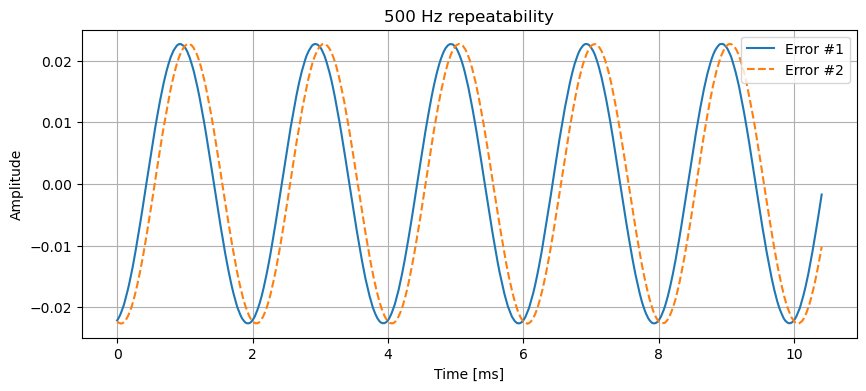

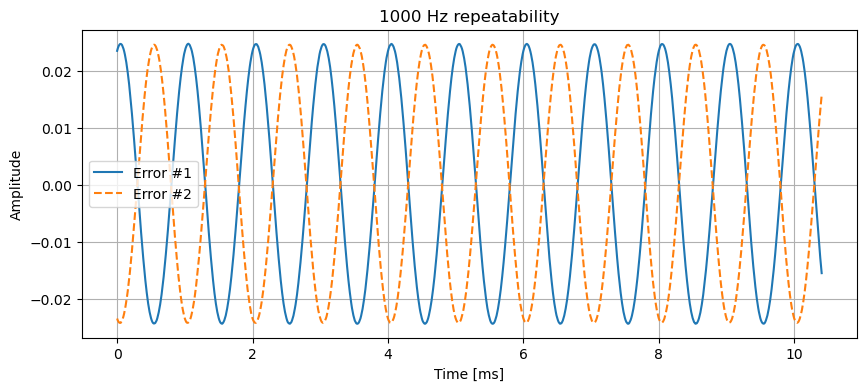

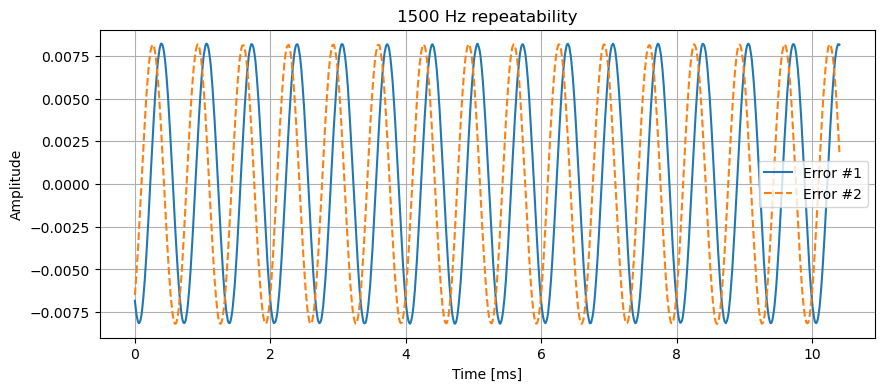

In [45]:
for freq, (e1, e2, r1, r2) in repeat_recordings.items():

    start = int(1.0 * fs)
    N = 1000

    plt.figure(figsize=(10, 4))

    plt.plot(
        np.arange(N) / fs * 1000,
        e1[start:start+N],
        label="Error #1",
    )

    plt.plot(
        np.arange(N) / fs * 1000,
        e2[start:start+N],
        "--",
        label="Error #2",
    )

    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude")
    plt.title(f"{freq} Hz repeatability")
    plt.grid()
    plt.legend()
    plt.show()